In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [43]:
start = "2020-01-01"
end = "2025-12-31"
stock = "GOOG"
data = yf.download(stock, start=start, end=end)
print(data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            GOOG        GOOG        GOOG        GOOG      GOOG
Date                                                                
2020-01-02   67.811775   67.849960   66.531287   66.531287  28132000
2020-01-03   67.478996   68.066178   66.729352   66.844208  23728000
2020-01-06   69.142838   69.256400   66.950335   66.950335  34646000
2020-01-07   69.099701   69.578270   68.952903   69.327831  30054000
2020-01-08   69.644218   70.004261   68.975703   69.037195  30560000
...                ...         ...         ...         ...       ...
2025-12-23  315.457764  316.077322  310.531242  310.915980  13961400
2025-12-24  315.447784  316.067343  313.099433  315.927427   6138200
2025-12-26  314.738251  316.337130  313.499133  315.697597   6730900
2025-12-29  314.168701  314.748279  311.680433  312.599799  12317700
2025-12-30  314.328552  317.476359  313.029480  313.189371  11052500

[1507 rows x 5 columns]


In [44]:
data.reset_index(inplace=True)

In [45]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2020-01-02,67.811775,67.849960,66.531287,66.531287,28132000
1,2020-01-03,67.478996,68.066178,66.729352,66.844208,23728000
2,2020-01-06,69.142838,69.256400,66.950335,66.950335,34646000
3,2020-01-07,69.099701,69.578270,68.952903,69.327831,30054000
4,2020-01-08,69.644218,70.004261,68.975703,69.037195,30560000
...,...,...,...,...,...,...
1502,2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
1503,2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
1504,2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900


In [46]:
ma_100 = data.Close.rolling(100).mean()

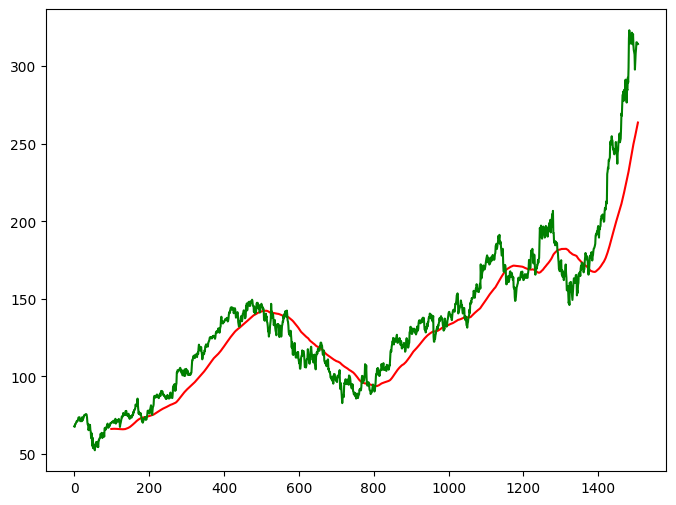

In [47]:
plt.figure(figsize=(8,6))
plt.plot(ma_100, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [48]:
ma_200 = data.Close.rolling(200).mean()

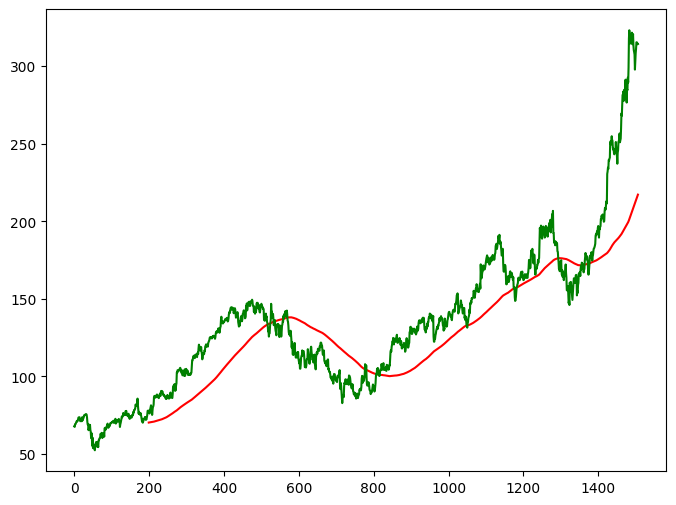

In [49]:
plt.figure(figsize=(8,6))
plt.plot(ma_200, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [50]:
data.dropna(inplace=True)

In [51]:
data_train = pd.DataFrame(data.Close[:int(len(data)*0.8)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.8):])

In [52]:
data_train.shape[0]

1205

In [53]:
data_test.shape[0]

302

In [54]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [55]:
data_train_scale = scaler.fit_transform(data_train)

In [56]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i])

In [57]:
x, y = np.array(x), np.array(y)

In [58]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [59]:
model = Sequential()
model.add(LSTM(units=50,  return_sequences=True, input_shape=(x.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,  return_sequences=True))
model.add(Dropout(0.3))
 
model.add(LSTM(units=80, return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120))
model.add(Dropout(0.5))

model.add(Dense(units=1))

c:\Users\Harshit\OneDrive\Desktop\Stock-Price Predictor ML\ml_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [60]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [61]:
model.fit(x,y, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0333
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0080
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0073
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0068
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0065
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0061
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0066
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0062
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0059
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0058
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0047
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0062
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0049
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - loss: 0.0049
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - l

In [62]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [63]:
past_100_days = data_train.tail(100)

In [64]:
data_test = pd.concat([past_100_days, data_test], ignore_index=True)

In [65]:
data_test_scale = scaler.transform(data_test)

In [66]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i])

x, y = np.array(x), np.array(y)

In [67]:
y_pred = model.predict(x)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


In [68]:
predicted = scaler.inverse_transform(y_pred)
actual = scaler.inverse_transform(y)

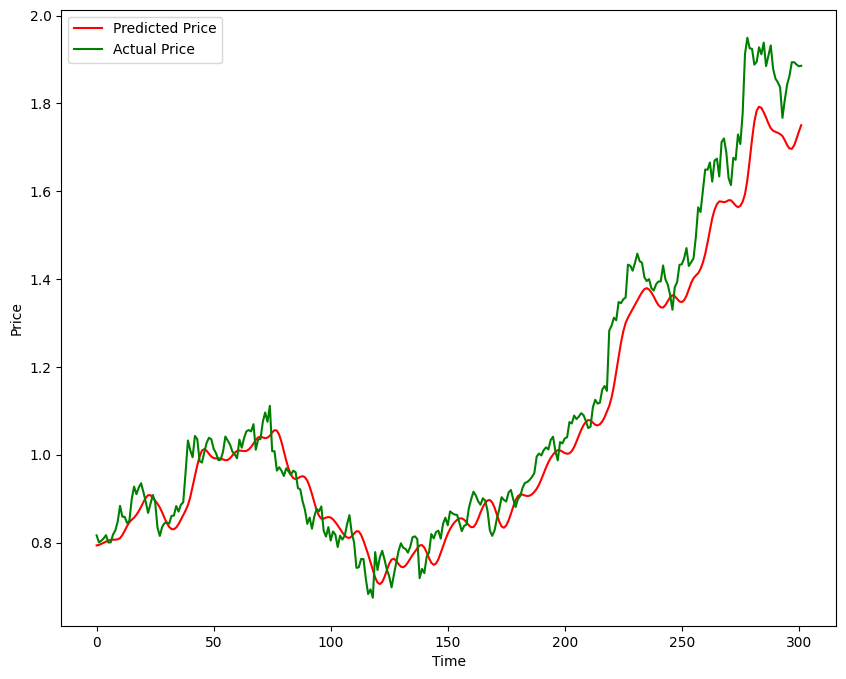

In [69]:
plt.figure(figsize=(10,8))
plt.plot(y_pred, 'r', label='Predicted Price')
plt.plot(y, 'g', label='Actual Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [70]:
predicted = model.predict(x)
predicted = scaler.inverse_transform(predicted)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [71]:
print(predicted[:10])

[[162.62311]
 [162.77094]
 [163.09717]
 [163.46396]
 [163.809  ]
 [164.14537]
 [164.37236]
 [164.43306]
 [164.4374 ]
 [164.53741]]


In [72]:
actual = scaler.inverse_transform(y)

for i in range(10):
    print(f"Predicted: {predicted[i][0]:.2f}, Actual: {actual[i][0]:.2f}")

Predicted: 162.62, Actual: 165.79
Predicted: 162.77, Actual: 163.57
Predicted: 163.10, Actual: 164.11
Predicted: 163.46, Actual: 164.85
Predicted: 163.81, Actual: 165.87
Predicted: 164.15, Actual: 163.54
Predicted: 164.37, Actual: 163.59
Predicted: 164.43, Actual: 166.04
Predicted: 164.44, Actual: 167.38
Predicted: 164.54, Actual: 170.16


In [73]:
results = pd.DataFrame({'Predicted': predicted.flatten(), 'Actual': actual.flatten()})
print(results.head(10))

    Predicted      Actual
0  162.623108  165.788376
1  162.770935  163.571106
2  163.097168  164.108032
3  163.463959  164.853729
4  163.809006  165.867935
5  164.145370  163.541260
6  164.372360  163.590988
7  164.433060  166.036942
8  164.437393  167.379227
9  164.537415  170.163269


In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actual, predicted)
mae = mean_absolute_error(actual, predicted)
r2 = r2_score(actual, predicted)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 115.22
Mean Absolute Error: 8.04
R-squared: 0.95


In [76]:
scaled_data = np.concatenate((data_train_scale, data_test_scale), axis=0)

In [77]:
last_60_days = scaled_data[-60:]
input_seq = last_60_days.reshape(1, -1, 1)

In [79]:
future_days = 7
future_predictions = []

for i in range(future_days):
    next_pred = model.predict(input_seq)

    future_predictions.append(next_pred[0][0])

    input_seq = np.append(input_seq[:,1:,:], next_pred.reshape(1, 1, -1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [80]:
print(input_seq.shape)

(1, 60, 1)


In [81]:
future_predictions = np.array(future_predictions).reshape(-1,1)
future_predictions = scaler.inverse_transform(future_predictions)

In [82]:
print("Next 7 Days Predicted Prices:\n")

for i, price in enumerate(future_predictions):
    print(f"Day {i+1}: ₹{price[0]:.2f}")

Next 7 Days Predicted Prices:

Day 1: ₹296.92
Day 2: ₹296.41
Day 3: ₹294.07
Day 4: ₹290.36
Day 5: ₹285.88
Day 6: ₹281.15
Day 7: ₹276.57


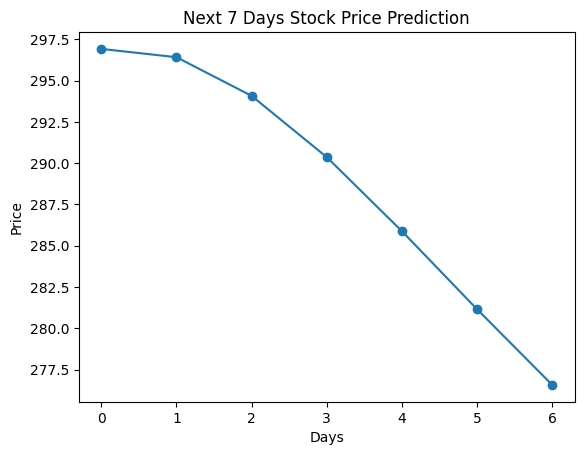

In [83]:
import matplotlib.pyplot as plt

plt.plot(future_predictions, marker='o')
plt.title("Next 7 Days Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [84]:
model.save('Stock_Price_Predictor.keras')